# Legal Document Summarization Pipeline
## Supreme Court Judgments (2020–2024)

A research-grade pipeline for extractive and abstractive summarization of legal documents.
Covers: PDF ingestion → OCR fallback → chunked summarization → batched evaluation → saved results.

> **Fixed issues:** chunking for long documents, batched BERTScore, no fake confidence, train/val/test split, inference timing, CSV output, consistent reference summaries.

---
## Phase 1 — Environment Setup

In [1]:
# Install requirements (run once)
# !pip install pdfplumber pymupdf pytesseract pillow opencv-python-headless
# !pip install transformers torch torchvision
# !pip install rouge_score bert_score
# !pip install sumy nltk scikit-learn pandas numpy tqdm pathlib networkx

In [2]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"
os.environ["USE_TF"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import os
import re
import cv2
import torch
import nltk
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pdfplumber
import pymupdf
import pytesseract

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx

from transformers import pipeline
from rouge_score import rouge_scorer
from bert_score import score as bert_score

nltk.download("punkt")
nltk.download("stopwords")


BASE_DIR = Path("./")
DATASET_DIR = Path(r"C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgments_2020_2024")
SPLITS_DIR = Path("./dataset/splits/")
ASSETS_DIR = Path("./assets/")
ASSETS_DIR.mkdir(exist_ok=True, parents=True)
SPLITS_DIR.mkdir(exist_ok=True, parents=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("Torch:", torch.__version__)

Device: cpu
Torch: 2.2.2+cpu


[nltk_data] Downloading package punkt to C:\Users\CHAITANYA
[nltk_data]     THAKUR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\CHAITANYA
[nltk_data]     THAKUR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# ── Computational Environment Snapshot ──────────────────────────────────────
import platform
import sys
import subprocess

def get_cpu_name():
    try:
        if platform.system() == "Windows":
            return platform.processor() or platform.uname().processor
        elif platform.system() == "Linux":
            with open("/proc/cpuinfo") as f:
                for line in f:
                    if "model name" in line:
                        return line.split(":")[1].strip()
        elif platform.system() == "Darwin":
            return subprocess.check_output(
                ["sysctl", "-n", "machdep.cpu.brand_string"]
            ).decode().strip()
    except Exception:
        pass
    return platform.processor() or "Unknown"

def get_ram_gb():
    try:
        import psutil
        return round(psutil.virtual_memory().total / (1024**3), 1)
    except ImportError:
        return "psutil not installed (pip install psutil)"

def get_package_version(pkg_name):
    try:
        module = __import__(pkg_name)
        return getattr(module, "__version__", "version attr not found")
    except ImportError:
        return "not installed"

env_report = {
    "OS":              platform.platform(),
    "CPU":             get_cpu_name(),
    "Logical cores":   os.cpu_count(),
    "RAM (GB)":        get_ram_gb(),
    "GPU":             torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None (CPU-only run)",
    "CUDA version":    torch.version.cuda if torch.cuda.is_available() else "N/A",
    "Python":          sys.version.split()[0],
    "PyTorch":         torch.__version__,
    "Transformers":    get_package_version("transformers"),
    "spaCy":           get_package_version("spacy"),
    "scikit-learn":    get_package_version("sklearn"),
    "NLTK":            get_package_version("nltk"),
    "rouge-score":     get_package_version("rouge_score"),
    "bert-score":      get_package_version("bert_score"),
    "pandas":          get_package_version("pandas"),
    "numpy":           get_package_version("numpy"),
}

env_df = pd.DataFrame(list(env_report.items()), columns=["Component", "Value"])
env_df.to_csv(ASSETS_DIR / "computational_environment.csv", index=False)
print(env_df.to_string(index=False))

    Component                                               Value
           OS                           Windows-11-10.0.22000-SP0
          CPU Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
Logical cores                                                   8
     RAM (GB)                                                15.8
          GPU                                 None (CPU-only run)
 CUDA version                                                 N/A
       Python                                              3.12.3
      PyTorch                                           2.2.2+cpu
 Transformers                                              4.50.2
        spaCy                                               3.8.5
 scikit-learn                                               1.3.2
         NLTK                                               3.8.1
  rouge-score                              version attr not found
   bert-score                                              0.3.12
       pan

---
## Phase 2 — PDF Ingestion & OCR

In [6]:
def get_first_pdf():
    """Return the first PDF found recursively under DATASET_DIR."""
    for file in DATASET_DIR.rglob("*.pdf"):
        return file
    return None

demo_pdf = get_first_pdf()
print("Demo PDF:", demo_pdf)

Demo PDF: C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgments_2020_2024\2020\Abhilasha_vs_Parkash_on_15_September_2020_1.PDF


In [7]:
def pdf_to_images(pdf_path):
    """Rasterise every page of a PDF to a numpy BGR array list."""
    doc = pymupdf.open(pdf_path)
    images = []
    for page in doc:
        pix = page.get_pixmap()
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        if pix.n == 4:
            img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)
        images.append(img)
    return images


def preprocess_image(img):
    """Return (gray, otsu_binary, clahe_enhanced) for one page image."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return gray, bin_img, enhanced


def deskew(img):
    """Correct page skew using minAreaRect on foreground pixels."""
    coords = np.column_stack(np.where(img > 0))
    if len(coords) == 0:
        return img
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

In [8]:
def extract_text(pdf_path):
    """
    3-layer text extraction:
      1. pdfplumber  (fastest, digital PDFs)
      2. PyMuPDF     (fallback for some encodings)
      3. Tesseract   (scanned / image-only PDFs)
    """
    text = ""

    # Layer 1 — pdfplumber
    try:
        with pdfplumber.open(pdf_path) as pdf:
            text = "\n".join([p.extract_text() or "" for p in pdf.pages])
    except Exception:
        pass

    # Layer 2 — PyMuPDF
    if len(text.split()) < 100:
        doc = pymupdf.open(pdf_path)
        text = "\n".join([p.get_text() for p in doc])

    # Layer 3 — OCR via Tesseract
    if len(text.split()) < 100:
        imgs = pdf_to_images(pdf_path)
        ocr_parts = []
        for img in imgs:
            _, bin_img, _ = preprocess_image(img)
            deskewed = deskew(bin_img)
            ocr_parts.append(pytesseract.image_to_string(deskewed))
        text = "\n".join(ocr_parts)

    text = re.sub(r"\n+", " ", text).strip()
    return text


raw_text = extract_text(demo_pdf)
print(f"Extracted {len(raw_text.split())} words from demo PDF")
print(raw_text[:800])

Extracted 7488 words from demo PDF
Abhilasha vs Parkash on 15 September, 2020 Abhilasha vs Parkash on 15 September, 2020 Equivalent citations: AIR 2020 SUPREME COURT 4355, AIRONLINE 2020 SC 727 Author: Ashok Bhushan Bench: M.R. Shah, R. Subhash Reddy, Ashok Bhushan REPORTABLE IN THE SUPREME COURT OF INDIA CRIMINAL APPELLATE JURISDICTION CRIMINAL APPEAL NO. 615 of 2020 (arising out of SLP (Crl.) No.8260/2018) ABHILASHA ...APPELLANT(S) VERSUS PARKASH & ORS. ...RESPONDENT(S) J U D G M E N T ASHOK BHUSHAN,J. Leave granted. 2. This appeal has been filed by the appellant, daughter of respondent Nos. 1 and 2, challenging the order of the High Court of Punjab and Haryana at Chandigarh dated 16.08.2018 by which order the High Court dismissed the application under Section 482 Cr.P.C. filed by the appellant praying for setting aside t


In [20]:
# ── OCR Accuracy Evaluation (CER / WER vs. digital-text ground truth) ───────
import os
import random
from concurrent.futures import ThreadPoolExecutor as ProcessPoolExecutor, as_completed

def digital_extract(pdf_path, max_pages=8):
    """Layers 1+2 only (no OCR) — used as pseudo-ground-truth for born-digital PDFs."""
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            text = "\n".join((p.extract_text() or "") for p in pdf.pages[:max_pages])
    except Exception:
        pass
    if len(text.split()) < 100:
        doc = pymupdf.open(pdf_path)
        text = "\n".join(page.get_text() for page in doc[:max_pages])
    return re.sub(r"\n+", " ", text).strip()

def digital_extract_pages(pdf_path, page_indices, max_pages=8):
    """Ground truth built ONLY from the page indices that survived OCR's
    readability filter, so dropped (unreadable) pages don't penalize the
    OCR-vs-ground-truth comparison as missing content."""
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            pages = pdf.pages[:max_pages]
            text = "\n".join((pages[i].extract_text() or "") for i in page_indices if i < len(pages))
    except Exception:
        pass
    if len(text.split()) < 50:
        doc = pymupdf.open(pdf_path)
        pages = list(doc)[:max_pages]
        text = "\n".join(pages[i].get_text() for i in page_indices if i < len(pages))
    return re.sub(r"\n+", " ", text).strip()

def forced_ocr_extract_indexed(pdf_path, max_pages=8, max_garbage_ratio=0.35, min_word_threshold=3):
    """Force pages through Tesseract on the raw rendered image — no binarization
    or deskew. Testing showed both steps degrade clean, upright, born-digital
    PDF renders: binarization introduces character confusions (C/L, N/W, I/T),
    and deskew was observed to clip/drop the top of the page. Those steps remain
    valuable for genuinely scanned/skewed paper documents (kept in the main
    extract_text pipeline) but are skipped here since this eval targets clean
    digital renders specifically."""
    imgs = pdf_to_images(pdf_path)[:max_pages]
    parts, kept_idx = [], []
    for i, img in enumerate(imgs):
        text = pytesseract.image_to_string(img)
        words = text.split()
        word_count = len(words)
        if word_count < min_word_threshold:
            continue
        short_frags = sum(1 for w in words if len(w) <= 2)
        garbage_ratio = short_frags / word_count
        if garbage_ratio <= max_garbage_ratio:
            parts.append(text)
            kept_idx.append(i)
    return re.sub(r"\n+", " ", " ".join(parts)).strip(), kept_idx
    
def edit_distance(seq_a, seq_b):
    """Levenshtein distance via dynamic programming (no extra dependency)."""
    n, m = len(seq_a), len(seq_b)
    if n == 0: return m
    if m == 0: return n
    dp = list(range(m + 1))
    for i in range(1, n + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, m + 1):
            tmp = dp[j]
            cost = 0 if seq_a[i - 1] == seq_b[j - 1] else 1
            dp[j] = min(dp[j] + 1, dp[j - 1] + 1, prev + cost)
            prev = tmp
    return dp[m]

def cer(reference, hypothesis):
    ref_chars = list(reference)
    if len(ref_chars) == 0:
        return 0.0 if len(hypothesis) == 0 else 1.0
    return edit_distance(ref_chars, list(hypothesis)) / len(ref_chars)

def wer(reference, hypothesis):
    ref_words = reference.split()
    if len(ref_words) == 0:
        return 0.0 if len(hypothesis.split()) == 0 else 1.0
    return edit_distance(ref_words, hypothesis.split()) / len(ref_words)

def extract_text_with_layer(pdf_path):
    """Same cascade as extract_text(), but also reports which layer fired (does not
    replace or alter the original extract_text — purely additive/diagnostic)."""
    text, layer = "", "pdfplumber"
    try:
        with pdfplumber.open(pdf_path) as pdf:
            text = "\n".join([p.extract_text() or "" for p in pdf.pages])
    except Exception:
        pass
    if len(text.split()) < 100:
        doc = pymupdf.open(pdf_path)
        text = "\n".join([p.get_text() for p in doc])
        layer = "pymupdf"
    if len(text.split()) < 100:
        imgs = pdf_to_images(pdf_path)
        ocr_parts = []
        for img in imgs:
            _, bin_img, _ = preprocess_image(img)
            deskewed = deskew(bin_img)
            ocr_parts.append(pytesseract.image_to_string(deskewed))
        text = "\n".join(ocr_parts)
        layer = "tesseract_ocr"
    return re.sub(r"\n+", " ", text).strip(), layer

random.seed(42)
all_pdfs = list(DATASET_DIR.rglob("*.pdf"))

# --- Part A: extraction-layer distribution on a sample ---
SAMPLE_SIZE = 200
layer_sample = random.sample(all_pdfs, min(SAMPLE_SIZE, len(all_pdfs)))

layer_counts = {}
for pdf_path in tqdm(layer_sample, desc="Tagging extraction layer"):
    _, layer = extract_text_with_layer(pdf_path)
    layer_counts[layer] = layer_counts.get(layer, 0) + 1

print("Extraction layer usage (sample of", len(layer_sample), "docs):")
for layer, count in layer_counts.items():
    pct = 100 * count / len(layer_sample)
    print(f"  {layer:15s}: {count:4d} docs ({pct:.1f}%)")

# --- Part B: CER/WER of the OCR layer, scored only on pages it actually attempted ---
MAX_PAGES_FOR_OCR_EVAL = 8

def eval_one_pdf(pdf_path, max_pages=MAX_PAGES_FOR_OCR_EVAL):
    ocr_text, kept_idx = forced_ocr_extract_indexed(pdf_path, max_pages=max_pages)
    if len(kept_idx) == 0:
        return None  # every page unreadable for this doc — skip
    gt_text = digital_extract_pages(pdf_path, kept_idx, max_pages=max_pages)
    if len(gt_text.split()) < 50:
        return None
    return {
        "path": str(pdf_path),
        "pages_kept": len(kept_idx),
        "pages_total": max_pages,
        "coverage": round(len(kept_idx) / max_pages, 2),
        "CER": round(cer(gt_text, ocr_text), 4),
        "WER": round(wer(gt_text, ocr_text), 4),
    }

ocr_sample = random.sample(all_pdfs, min(10, len(all_pdfs)))
ocr_eval_rows = []

with ProcessPoolExecutor(max_workers=min(os.cpu_count() or 4, len(ocr_sample))) as ex:
    futures = {ex.submit(eval_one_pdf, p): p for p in ocr_sample}
    for f in tqdm(as_completed(futures), total=len(futures), desc="OCR accuracy eval"):
        r = f.result()
        if r is not None:
            ocr_eval_rows.append(r)

ocr_eval_df = pd.DataFrame(ocr_eval_rows)
ocr_eval_df.to_csv(ASSETS_DIR / "ocr_accuracy.csv", index=False)

print(f"\nOCR evaluated on {len(ocr_eval_df)} born-digital docs (Tesseract forced, "
      f"scored only on pages it could read, vs pdfplumber/PyMuPDF ground truth "
      f"for those same pages, capped at {MAX_PAGES_FOR_OCR_EVAL} pages/doc):")
if len(ocr_eval_df) > 0:
    print(f"  Mean CER: {ocr_eval_df['CER'].mean():.4f}  "
          f"({(1 - ocr_eval_df['CER'].mean()) * 100:.2f}% character accuracy)")
    print(f"  Mean WER: {ocr_eval_df['WER'].mean():.4f}  "
          f"({(1 - ocr_eval_df['WER'].mean()) * 100:.2f}% word accuracy)")
    print(f"  Mean page coverage (readable pages / attempted pages): "
          f"{ocr_eval_df['coverage'].mean()*100:.1f}%")

Tagging extraction layer: 100%|██████████████████████████████████████████████████████| 200/200 [19:48<00:00,  5.94s/it]


Extraction layer usage (sample of 200 docs):
  pdfplumber     :  200 docs (100.0%)


OCR accuracy eval: 100%|████████████████████████████████████████████████████████████| 10/10 [2:03:46<00:00, 742.68s/it]


OCR evaluated on 10 born-digital docs (Tesseract forced, scored only on pages it could read, vs pdfplumber/PyMuPDF ground truth for those same pages, capped at 8 pages/doc):
  Mean CER: 0.0539  (94.61% character accuracy)
  Mean WER: 0.1236  (87.64% word accuracy)
  Mean page coverage (readable pages / attempted pages): 91.2%


---
## Phase 3 — Document Classification & Authentication

> **Note:** Classification below is a rule-based heuristic (keyword matching). No probability/confidence score is reported because heuristics do not yield calibrated probabilities. This is stated explicitly and labelled as a preprocessing step, not a learned classifier.

In [24]:
def classify(text):
    """
    Rule-based document type heuristic.
    Returns a string label only — no confidence score,
    because keyword rules do not produce calibrated probabilities.
    """
    t = text[:2000].upper()
    if "CRIMINAL" in t:
        return "Criminal"
    elif "CIVIL" in t:
        return "Civil"
    elif "WRIT" in t:
        return "Constitutional"
    return "Unknown"


def authenticate(text):
    """
    Heuristic authenticity check based on structural markers.
    Returns (status_label, integer_score_out_of_4).
    """
    score = 0
    t = text.upper()
    if "SUPREME COURT" in t:
        score += 1
    if re.search(r"(CRIMINAL|CIVIL).*APPEAL.*\d+", t):
        score += 1
    if re.search(r"20\d{2}", text):
        score += 1
    if re.search(r"JUSTICE|HON'?BLE", t):
        score += 1
    return ("AUTHENTICATED" if score >= 3 else "SUSPICIOUS", score)


label   = classify(raw_text)
status, auth_score = authenticate(raw_text)

print(f"Classification  : {label}  (rule-based heuristic)")
print(f"Authentication  : {status}  (score {auth_score}/4)")

Classification  : Criminal  (rule-based heuristic)
Authentication  : AUTHENTICATED  (score 4/4)


In [26]:
# ── Classification Accuracy: Step A — generate sample for manual labelling ──
import random
from pathlib import Path

random.seed(7)

all_pdfs = list(DATASET_DIR.rglob("*.pdf"))
CLASS_SAMPLE_SIZE = 60
class_sample_pdfs = random.sample(all_pdfs, min(CLASS_SAMPLE_SIZE, len(all_pdfs)))

class_eval_rows = []
for pdf_path in tqdm(class_sample_pdfs, desc="Classifying sample"):
    text = extract_text(pdf_path)
    pred_label = classify(text)
    pred_status, pred_score = authenticate(text)
    class_eval_rows.append({
        "path": str(pdf_path),
        "predicted_label": pred_label,
        "predicted_auth_status": pred_status,
        "predicted_auth_score": pred_score,
        "ground_truth_label": "",       # fill manually: Criminal / Civil / Constitutional / Unknown
        "ground_truth_authentic": "",   # fill manually: Y / N
    })

class_eval_df = pd.DataFrame(class_eval_rows)

# Define the Downloads directory path dynamically
downloads_dir = Path.home() / "Downloads"
output_path = downloads_dir / "classification_accuracy_sample.csv"

class_eval_df.to_csv(output_path, index=False)
print(f"Wrote {len(class_eval_df)} rows to {output_path}.")
print("Open it, fill 'ground_truth_label' and 'ground_truth_authentic', then run Step B.")

Classifying sample: 100%|██████████████████████████████████████████████████████████████| 60/60 [06:33<00:00,  6.55s/it]

Wrote 60 rows to C:\Users\CHAITANYA THAKUR\Downloads\classification_accuracy_sample.csv.
Open it, fill 'ground_truth_label' and 'ground_truth_authentic', then run Step B.


In [40]:
# ── Classification Accuracy: Step B — run after manually filling the CSV ────
from pathlib import Path
from sklearn.metrics import classification_report, accuracy_score

# Define the Downloads directory path dynamically
downloads_dir = Path.home() / "Downloads"
input_path = downloads_dir / "classification_accuracy_sample.csv"

labelled = pd.read_csv(input_path)
labelled = labelled[labelled["ground_truth_label"].notna() & (labelled["ground_truth_label"] != "")]

if len(labelled) == 0:
    print(f"No manually labelled rows found yet — fill in ground_truth_label in {input_path} first.")
else:
    print("Document-type classification report:")
    print(classification_report(
        labelled["ground_truth_label"], labelled["predicted_label"], zero_division=0
    ))

    auth_labelled = labelled[labelled["ground_truth_authentic"].notna() & (labelled["ground_truth_authentic"] != "")]
    if len(auth_labelled) > 0:
        gt_auth = auth_labelled["ground_truth_authentic"].str.upper().map(
            {"Y": "AUTHENTICATED", "N": "SUSPICIOUS"}
        )
        acc = accuracy_score(gt_auth, auth_labelled["predicted_auth_status"])
        print(f"\nAuthentication heuristic accuracy: {acc:.4f}  (n={len(auth_labelled)})")

Document-type classification report:
                precision    recall  f1-score   support

         Civil       0.94      1.00      0.97        30
Constitutional       0.00      0.00      0.00         2
      Criminal       1.00      1.00      1.00        27
       Unknown       1.00      1.00      1.00         1

      accuracy                           0.97        60
     macro avg       0.73      0.75      0.74        60
  weighted avg       0.94      0.97      0.95        60


Authentication heuristic accuracy: 0.9667  (n=60)


In [30]:
from pathlib import Path

# Define the Downloads directory path dynamically
downloads_dir = Path.home() / "Downloads"
input_path = downloads_dir / "classification_accuracy_sample.csv"

sample_df = pd.read_csv(input_path)
for i, row in sample_df.iterrows():
    text = extract_text(row["path"])
    
    # Using Path safely handles both Windows (\) and Mac/Linux (/) paths
    fname = Path(row["path"]).name
    
    print(f"[{i}] {fname}")
    print(text[:400])
    print("-" * 80)

[0] Ram_Vijay_Singh_vs_State_Of_U_P_on_25_February_2021_1.PDF
Ram Vijay Singh vs State Of U.P. on 25 February, 2021 Ram Vijay Singh vs State Of U.P. on 25 February, 2021 Equivalent citations: AIRONLINE 2021 SC 118 Author: Hemant Gupta Bench: B.R. Gavai, Hemant Gupta, Rohinton Fali Nariman REPORTABLE IN THE SUPREME COURT OF INDIA CRIMINAL APPELLATE JURISDICTION CRIMINAL APPEAL NO. 175 OF 2021 (ARISING OUT OF SLP (CRIMINAL) NO. 2898 OF 2020) RAM VIJAY SINGH ..
--------------------------------------------------------------------------------
[1] Tej_Bhan_D_Through_Lr_vs_Ram_Kishan_D_Through_Lrs_on_9_December_2024_1.PDF
Tej Bhan(D) Through Lr vs Ram Kishan (D) Through Lrs on 9 December, 2024 Tej Bhan(D) Through Lr vs Ram Kishan (D) Through Lrs on 9 December, 2024 Author: Pamidighantam Sri Narasimha Bench: Pamidighantam Sri Narasimha REPORTABLE 2024 INSC 945 IN THE SUPREME COURT OF INDIA CIVIL APPELLATE JURISDICTION CIVIL APPEAL NO. 6557 OF 2022 TEJ BHAN (D) THROUGH LR. & ORS. ...APPELLANT(S

---
## Phase 4 — Chunking Strategy for Long Documents

Supreme Court judgments are 10 000–50 000+ words. Truncating at 2 000 characters summarises only the header. The sliding-window chunker below splits text into overlapping chunks, summarises each, then optionally applies a second-pass (hierarchical) summary if the merged result is still too long.

In [12]:
def chunk_text(text, max_chars=3000, overlap=200):
    """
    Split `text` into overlapping windows of `max_chars` characters.
    Returns a list of string chunks.
    """
    chunks, start = [], 0
    while start < len(text):
        chunks.append(text[start: start + max_chars])
        start += max_chars - overlap
    return chunks

---
## Phase 5 — Load Summarization Models

In [14]:
bart_pipe = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=0 if device == "cuda" else -1
)

t5_pipe = pipeline(
    "summarization",
    model="t5-small",
    device=0 if device == "cuda" else -1
)

print("Models loaded.")

Device set to use cpu
Device set to use cpu


Models loaded.


---
## Phase 6 — Summarization Functions

In [16]:
# ── Extractive: TF-IDF ──────────────────────────────────────────────────────

def tfidf_summary(text, k=5):
    """Select top-k sentences by cumulative TF-IDF score."""
    sents = [s.strip() for s in text.split(".") if len(s.split()) > 5]
    if len(sents) <= k:
        return ". ".join(sents)
    vec = TfidfVectorizer()
    X = vec.fit_transform(sents)
    scores = X.sum(axis=1).A1
    ranked = [sents[i] for i in scores.argsort()[::-1]]
    return ". ".join(ranked[:k])


# ── Extractive: TextRank ────────────────────────────────────────────────────

def textrank_summary(text, k=5):
    """Graph-based sentence ranking via PageRank on cosine-similarity matrix."""
    sents = [s.strip() for s in text.split(".") if len(s.split()) > 5]
    if len(sents) <= k:
        return ". ".join(sents)
    vec = TfidfVectorizer()
    X   = vec.fit_transform(sents)
    sim = cosine_similarity(X)
    graph  = nx.from_numpy_array(sim)
    scores = nx.pagerank(graph)
    ranked = sorted(((scores[i], s) for i, s in enumerate(sents)), reverse=True)
    return ". ".join([s for _, s in ranked[:k]])


# ── Abstractive: BART (chunked + hierarchical) ──────────────────────────────

def bart_summary(text):
    """
    Chunk-then-summarize strategy:
      1. Split into overlapping 3 000-char windows.
      2. Summarise each chunk independently.
      3. If the merged chunk summaries exceed 300 words, apply a
         second-pass (hierarchical) summary over the concatenation.
    """
    chunks = chunk_text(text, max_chars=3000, overlap=200)
    chunk_summaries = [
        bart_pipe(c, max_length=150, min_length=40, do_sample=False)[0]["summary_text"]
        for c in chunks
    ]
    combined = " ".join(chunk_summaries)
    if len(combined.split()) > 300:
        combined = bart_pipe(
            combined[:3000], max_length=200, min_length=50, do_sample=False
        )[0]["summary_text"]
    return combined


# ── Abstractive: T5 (chunked + hierarchical) ────────────────────────────────

def t5_summary(text):
    """
    Same chunk-then-summarize strategy as bart_summary, adapted for T5.
    """
    chunks = chunk_text(text, max_chars=3000, overlap=200)
    chunk_summaries = [
        t5_pipe("summarize: " + c, max_length=150, min_length=40, do_sample=False)[0]["summary_text"]
        for c in chunks
    ]
    combined = " ".join(chunk_summaries)
    if len(combined.split()) > 300:
        combined = t5_pipe(
            "summarize: " + combined[:3000], max_length=200, min_length=50, do_sample=False
        )[0]["summary_text"]
    return combined

---
## Phase 7 — Single-Document Demo

In [18]:
import time

demo_results = {}
for name, fn in [("TFIDF", tfidf_summary), ("TextRank", textrank_summary),
                  ("BART",  bart_summary),  ("T5",      t5_summary)]:
    t0 = time.time()
    demo_results[name] = fn(raw_text)
    elapsed = time.time() - t0
    print(f"\n{'─'*60}")
    print(f"[{name}]  ({elapsed:.1f}s)")
    print(demo_results[name][:500])


────────────────────────────────────────────────────────────
[TFIDF]  (0.1s)
It was pointed out in Shah Bano's case that since that right could be defeated by the husband by divorcing her unilaterally under the Muslim Personal Law or by obtaining a decree of divorce under any other system of law, it was considered desirable to remove the hardship by extending the benefit of the provisions of the section to a divorced woman so long as she did not remarry, and that was achieved by including Clause (b) of the Explanation. As regards grant of maintenance to Abhilasha by the 

────────────────────────────────────────────────────────────
[TextRank]  (0.9s)
Although, the High Court and this Court had declined to interfere with the order of the Family Court taking the cue from Section 20(3) of the Act, 1956 under which the right of maintenance is given to a minor daughter till her marriage, but the judgment of this Court in Jagdish Jugtawat (supra) cannot be read to laying down the ratio that

Your max_length is set to 150, but your input_length is only 88. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=44)
Token indices sequence length is longer than the specified maximum sequence length for this model (800 > 512). Running this sequence through the model will result in indexing errors



────────────────────────────────────────────────────────────
[BART]  (359.5s)
The appeal has been filed by the appellant, daughter of respondent Nos. 1 and 2, challenging the order of the High Court of Punjab and Haryana at Chandigarh dated 16.08.2018. The Maintenance Act is an act to amend and codify the law relating to adoptions and maintenance among Hindus.


Your max_length is set to 150, but your input_length is only 103. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=51)



────────────────────────────────────────────────────────────
[T5]  (124.7s)
the appeal has been filed by the appellant, daughter of respondent no. 1 and 2, challenging the order of the High Court of Punjab and Haryana at Chandigarh . a criminal revision was dismissed by learned Additional Sessions Judge by order dated 16.02.2011 with the only modification that revisionist No.4 shall be entitled to maintenance till 26.04.2005 . no case was made out to interfere in orders passed by the Judicial Magistrate and learned Revisional Court .


---
## Phase 8 — Dataset Loading (Recursive, Year-Wise Folders)

In [20]:
def load_dataset(min_words=200):
    """
    Recursively discover all .pdf files under DATASET_DIR.
    Returns a DataFrame with columns: path, year, text, words.
    Rows with fewer than `min_words` are dropped.
    """
    files = list(DATASET_DIR.rglob("*.pdf"))
    data  = []
    for f in tqdm(files, desc="Loading PDFs"):
        text = extract_text(f)
        # Infer year from parent folder name if numeric
        year = f.parent.name if f.parent.name.isdigit() else "unknown"
        data.append({"path": str(f), "year": year,
                     "text": text, "words": len(text.split())})
    df = pd.DataFrame(data)
    df = df[df["words"] >= min_words].reset_index(drop=True)
    return df


df = load_dataset()
print(f"\nDocuments retained: {len(df)}")
print(df[["year", "words"]].describe())

Loading PDFs: 100%|██████████████████████████████████████████████████████████████| 2000/2000 [3:01:51<00:00,  5.46s/it]


Documents retained: 1999
               words
count    1999.000000
mean     9873.942971
std     12780.333229
min       210.000000
25%      3699.000000
50%      6028.000000
75%     10811.500000
max    136343.000000


---
## Phase 9 — Train / Val / Test Split (Saved to CSV)

In [22]:
from sklearn.model_selection import train_test_split

# 70 / 15 / 15 stratified by year where possible
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42,
                                     stratify=df["year"] if df["year"].nunique() > 1 else None)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42)

train_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(  SPLITS_DIR / "val.csv",   index=False)
test_df.to_csv( SPLITS_DIR / "test.csv",  index=False)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print(f"Splits saved to {SPLITS_DIR}")

Train: 1399  |  Val: 300  |  Test: 300
Splits saved to dataset\splits


---
## Phase 10 — Reference Summary Extraction

The headnote heuristic: text **before** the word `JUDGMENT` (or first 200 words if absent), bounded to 150–400 words so that all reference summaries have comparable length.

In [24]:
def reference_summary(text, min_words=150, max_words=400):
    """
    Extract headnote as pseudo-reference.
    - Looks for text before 'JUDGMENT'.
    - Falls back to the first `max_words` words.
    - Enforces min/max word bounds to keep references comparable.
    """
    idx = text.upper().find("JUDGMENT")
    candidate = text[:idx] if idx != -1 else text
    words = candidate.split()

    if len(words) < min_words:
        # Too short — take first max_words of full text instead
        words = text.split()[:max_words]
    else:
        words = words[:max_words]

    return " ".join(words)

---
## Phase 11 — Full Evaluation Batch (Test Split)

Inference time is recorded per model. All outputs are saved incrementally so nothing is lost if the kernel dies mid-run.

In [29]:
import time
from tqdm import tqdm
import pandas as pd

def trim_text(text, max_words=600):
    return " ".join(text.split()[:max_words])

MODELS = {
    "tfidf": tfidf_summary,
    "textrank": textrank_summary,
    "bart": bart_summary,
    "t5": t5_summary,
}

rows = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Summarising test set"):

    # input compression
    text = trim_text(row["text"], max_words=600)

    # IMPORTANT: full text for evaluation correctness
    ref = reference_summary(row["text"])

    entry = {
        "path": row["path"],
        
        "year": row.get("year", None),
        "ref": ref
    }

    for model_name, fn in MODELS.items():
        try:
            t0 = time.time()

            output = fn(text)

            entry[model_name] = output
            entry[f"{model_name}_sec"] = round(time.time() - t0, 2)

        except Exception as exc:
            entry[model_name] = ""
            entry[f"{model_name}_sec"] = -1
            print(f"⚠ {model_name} failed on {row['path']}: {exc}")

    rows.append(entry)

results_df = pd.DataFrame(rows)
results_df.to_csv(ASSETS_DIR / "results_raw.csv", index=False)

print(results_df.shape)

Summarising test set:   7%|████▏                                                    | 22/300 [18:22<3:50:32, 49.76s/it]

⚠ bart failed on C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgments_2020_2024\2023\Vivek_Narayan_Sharma_vs_Union_Of_India_on_2_January_2023_1.PDF: index out of range in self


Summarising test set:  12%|██████▊                                                  | 36/300 [29:05<3:42:57, 50.67s/it]

⚠ bart failed on C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgments_2020_2024\2020\The_Pharmacy_Council_Of_India_vs_Dr_S_K_Toshniwal_Educational_Trusts_on_5_March_2020_1.PDF: index out of range in self


Summarising test set:  14%|████████▏                                                | 43/300 [34:24<3:27:40, 48.49s/it]

...

⚠ bart failed on C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgments_2020_2024\2022\Rashidul_Jafar_Chota_vs_The_State_Of_Uttar_Pradesh_on_6_September_2022_1.PDF: index out of range in self


Summarising test set:  79%|████████████████████████████████████████████            | 236/300 [2:36:45<24:07, 22.62s/it]Your max_length is set to 150, but your input_length is only 134. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=67)
Your max_length is set to 150, but your input_length is only 145. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=72)
Summarising test set:  82%|█████████████████████████████████████████████▉          | 246/300 [2:41:02<23:23, 25.99s/it]

⚠ bart failed on C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgments_2020_2024\2022\Union_Of_India_vs_Ex_Hc_Gd_Virender_Singh_on_22_August_2022_1.PDF: index out of range in self


Summarising test set: 100%|████████████████████████████████████████████████████████| 300/300 [3:22:42<00:00, 40.54s/it]


(300, 11)


---
## Phase 12 — ROUGE Evaluation

In [31]:
def rouge_eval(ref, hyp):
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    return scorer.score(ref, hyp)


rouge_rows = []

for model_name in MODELS:
    r1, r2, rl = [], [], []
    for _, row in results_df.iterrows():
        if not row[model_name]:          # skip failed rows
            continue
        s = rouge_eval(row["ref"], row[model_name])
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)
    rouge_rows.append({
        "model":   model_name,
        "ROUGE-1": round(np.mean(r1), 4),
        "ROUGE-2": round(np.mean(r2), 4),
        "ROUGE-L": round(np.mean(rl), 4),
        "avg_sec": round(results_df[f"{model_name}_sec"].mean(), 2),
    })

rouge_df = pd.DataFrame(rouge_rows)
print(rouge_df.to_string(index=False))

   model  ROUGE-1  ROUGE-2  ROUGE-L  avg_sec
   tfidf   0.4927   0.3937   0.3106     0.01
textrank   0.4405   0.3478   0.2932     0.02
    bart   0.2898   0.1941   0.2305    28.56
      t5   0.2787   0.1919   0.2179    11.89


In [37]:
print(results_df[["model"] if "model" in results_df.columns else results_df.columns])
print(results_df.head())


for col in ["tfidf", "textrank", "bart", "t5"]:
    print(col, results_df[col].apply(lambda x: isinstance(x, str) and len(x.strip()) > 0).sum())

                                                  path  year  \
0    C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2022   
1    C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2021   
2    C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2021   
3    C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2021   
4    C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2023   
..                                                 ...   ...   
295  C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2022   
296  C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2024   
297  C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2022   
298  C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2020   
299  C:\Users\CHAITANYA THAKUR\Downloads\SC_Judgmen...  2022   

                                                   ref  \
0    Bhag Singh Etc. Etc. vs Union Of India And Anr...   
1    Sgs India Ltd. vs Dolphin International Ltd. o...   
2    Triyambak S.Hegde vs Sripad on 23 September, 2...   

---
## Phase 13 — BERTScore Evaluation (Batched)

BERTScore loads RoBERTa **once per model** over the entire test set in a single batched call, instead of per-document (which would be ~100× slower and potentially crash).

In [44]:
import numpy as np
from bert_score import score as bert_score
from tqdm import tqdm

refs = results_df["ref"].fillna("").tolist()

BATCH_SIZE = 16  # smaller = more stable + visible progress

bert_rows = []

for model_name in tqdm(MODELS, desc="Models (BERTScore)"):
    
    hyps = results_df[model_name].fillna("").tolist()

    valid_pairs = [
        (h, r)
        for h, r in zip(hyps, refs)
        if isinstance(h, str) and len(h.strip()) > 20
        and isinstance(r, str) and len(r.strip()) > 20
    ]

    if len(valid_pairs) < 5:
        bert_rows.append({"model": model_name, "BERTScore-F1": None})
        continue

    h_clean, r_clean = zip(*valid_pairs)

    all_f1 = []

    batch_iter = range(0, len(h_clean), BATCH_SIZE)

    for i in tqdm(batch_iter, desc=f"{model_name} batches", leave=False):

        batch_h = list(h_clean[i:i+BATCH_SIZE])
        batch_r = list(r_clean[i:i+BATCH_SIZE])

        _, _, F1 = bert_score(
            batch_h,
            batch_r,
            model_type="roberta-base",   # MUCH FASTER than large
            lang="en",
            device=device,
            verbose=False
        )

        all_f1.append(F1)

    all_f1 = np.concatenate(all_f1)
    score = round(float(all_f1.mean()), 4)

    bert_rows.append({
        "model": model_name,
        "BERTScore-F1": score
    })

    print(f"✔ {model_name}: {score}")

bert_df = pd.DataFrame(bert_rows)

tfidf batches:   0%|                                                                            | 0/19 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

✔ textrank: 0.8227



bart batches:   0%|                                                                             | 0/18 [00:00<?, ?it/s]Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

bart batches:   6%|███▊                                                                 | 1/18 [00:30<08:35, 30.32s/it]Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

bart batches:  11%|███████▋                                                             | 2/18 [01:00<08:06, 30.43s/it]Some weights of RobertaModel were not initialized from the model checkpoint at roberta-bas

✔ bart: 0.8231



t5 batches:   0%|                                                                               | 0/19 [00:00<?, ?it/s]Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

t5 batches:   5%|███▋                                                                   | 1/19 [00:30<09:02, 30.13s/it]Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

t5 batches:  11%|███████▍                                                               | 2/19 [01:00<08:29, 29.99s/it]Some weights of RobertaModel were not initialized from the model checkpoint at roberta-bas

✔ t5: 0.802


In [44]:
# ── FAST RECOVERY: reload already-computed results instead of re-running the pipeline ──
import pandas as pd
from pathlib import Path
from rouge_score import rouge_scorer

ASSETS_DIR = Path("./assets/")
SPLITS_DIR = Path("./dataset/splits/")

# Skip Phase 8 (corpus-wide OCR) — load the test split's text directly
df = pd.read_csv(SPLITS_DIR / "test.csv")     # has path, year, text, words — same as Phase 8's df
test_df = df.copy()

# Skip Phase 11 (BART/T5 inference) — load the already-generated summaries
results_df = pd.read_csv(ASSETS_DIR / "results_raw.csv")

# Phase 12's function — instant, no recomputation, just a definition
def rouge_eval(ref, hyp):
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    return scorer.score(ref, hyp)

print(f"Recovered df: {len(df)} rows  |  results_df: {len(results_df)} rows")

Recovered df: 300 rows  |  results_df: 300 rows


In [46]:
# ── Error Analysis: per-document diagnostics for BART & T5 ──────────────────
import re as _re

LEGAL_TERMS = [
    "writ", "petitioner", "respondent", "appellant", "appellee", "tribunal",
    "interlocutory", "certiorari", "mandamus", "habeas corpus", "locus standi",
    "ratio decidendi", "obiter dicta", "res judicata", "suo motu", "ultra vires",
    "ex parte", "in limine", "estoppel", "injunction", "decree", "plaintiff",
    "appellate", "jurisdiction", "affidavit", "adjudication",
]

def legal_term_density(text):
    t = text.lower()
    hits = sum(t.count(term) for term in LEGAL_TERMS)
    return hits / max(len(text.split()), 1)

def repetition_ratio(text, n=4):
    """Proxy for hallucination/looping: fraction of repeated n-grams."""
    words = text.split()
    if len(words) < n + 1:
        return 0.0
    ngrams = [" ".join(words[i:i + n]) for i in range(len(words) - n + 1)]
    return 1 - (len(set(ngrams)) / len(ngrams))

def numeric_fact_overlap(ref, hyp):
    """Fraction of numbers/years in the reference that also appear in the hypothesis —
    a proxy for 'missing legal facts' (dates, section numbers, amounts)."""
    ref_nums = set(_re.findall(r"\b\d{2,4}\b", ref))
    if not ref_nums:
        return 1.0
    hyp_nums = set(_re.findall(r"\b\d{2,4}\b", hyp))
    return len(ref_nums & hyp_nums) / len(ref_nums)

error_rows = []
for _, row in results_df.iterrows():
    ref = row["ref"]
    for model_name in ["bart", "t5"]:
        hyp = row.get(model_name, "")
        if not isinstance(hyp, str) or not hyp.strip():
            continue
        rl = rouge_eval(ref, hyp)["rougeL"].fmeasure
        error_rows.append({
            "path": row["path"],
            "model": model_name,
            "ROUGE-L": round(rl, 4),
            "repetition_ratio": round(repetition_ratio(hyp), 4),
            "numeric_fact_overlap": round(numeric_fact_overlap(ref, hyp), 4),
            "ref": ref,
            "hyp": hyp,
        })

error_df = pd.DataFrame(error_rows)

# Attach source length & legal-term density from the corpus-level df (Phase 8)
try:
    src_lookup = df.set_index("path")[["words", "text"]]
    error_df["src_words"] = error_df["path"].map(src_lookup["words"])
    error_df["legal_term_density_src"] = error_df["path"].map(src_lookup["text"]).apply(
        lambda t: legal_term_density(t) if isinstance(t, str) else None
    )
except NameError:
    error_df["src_words"] = None
    error_df["legal_term_density_src"] = None
    print("Note: `df` (Phase 8) not found in memory — re-run that cell to attach "
          "source length / legal-term density columns.")

def tag_failure_reason(r):
    reasons = []
    if r["src_words"] is not None and r["src_words"] > 8000:
        reasons.append("Long judgment (heavy truncation risk)")
    if r["repetition_ratio"] > 0.15:
        reasons.append("Repetition / possible hallucination")
    if r["numeric_fact_overlap"] < 0.3:
        reasons.append("Missing legal facts (dates/sections/amounts dropped)")
    if (r["legal_term_density_src"] is not None and r["legal_term_density_src"] > 0.01
            and r["ROUGE-L"] < 0.25):
        reasons.append("Complex legal terminology mishandled")
    return "; ".join(reasons) if reasons else "No flagged pattern"

error_df["failure_reason"] = error_df.apply(tag_failure_reason, axis=1)

worst_cases = (
    error_df.sort_values("ROUGE-L")
    .groupby("model", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)
worst_cases.to_csv(ASSETS_DIR / "error_analysis_worst_cases.csv", index=False)

print(worst_cases[["model", "ROUGE-L", "failure_reason"]].to_string(index=False))

print("\n--- Qualitative examples (paste excerpts into the paper's Error Analysis section) ---")
for _, r in worst_cases.head(6).iterrows():
    print("=" * 100)
    print(f"Model: {r['model']}   ROUGE-L: {r['ROUGE-L']}   Failure reason: {r['failure_reason']}")
    print(f"Reference (excerpt): {r['ref'][:300]}...")
    print(f"Generated (excerpt): {r['hyp'][:300]}...")

model  ROUGE-L                                                                                                                    failure_reason
   t5   0.0609                                       Long judgment (heavy truncation risk); Missing legal facts (dates/sections/amounts dropped)
   t5   0.0696                                       Long judgment (heavy truncation risk); Missing legal facts (dates/sections/amounts dropped)
   t5   0.0703  Long judgment (heavy truncation risk); Repetition / possible hallucination; Missing legal facts (dates/sections/amounts dropped)
   t5   0.0708                                       Long judgment (heavy truncation risk); Missing legal facts (dates/sections/amounts dropped)
   t5   0.0880                                       Long judgment (heavy truncation risk); Missing legal facts (dates/sections/amounts dropped)
 bart   0.1151                                       Long judgment (heavy truncation risk); Missing legal facts (dates/sections/am

In [48]:
# ── Sample Output Table: one representative document, all model outputs ────
sample_row = results_df.iloc[5]   # pick any row; ideally one near-median ROUGE-L for representativeness

original_excerpt = sample_row.get("text", "")  # only present if results_df carries full text; else re-extract:
if not original_excerpt:
    matched = df[df["path"] == sample_row["path"]]
    original_excerpt = matched["text"].values[0] if len(matched) else ""

sample_table_rows = [
    {"Component": "Original Text (excerpt)", "Content": original_excerpt[:600] + "..."},
    {"Component": "Reference Headnote",       "Content": sample_row["ref"]},
    {"Component": "TF-IDF Output",             "Content": sample_row["tfidf"]},
    {"Component": "TextRank Output",           "Content": sample_row["textrank"]},
    {"Component": "BART Output",               "Content": sample_row["bart"]},
    {"Component": "T5 Output",                 "Content": sample_row["t5"]},
]

sample_table_df = pd.DataFrame(sample_table_rows)
sample_table_df.to_csv(ASSETS_DIR / "sample_output_table.csv", index=False)
print(sample_table_df.to_string(index=False))

              Component                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

---
## Phase 14 — Final Results Table (Saved to CSV)

In [46]:
import pandas as pd

# Merge results safely
final_df = rouge_df.merge(bert_df, on="model", how="inner")

# Ensure numeric stability (important for real datasets)
metric_cols = [c for c in final_df.columns if c != "model"]
final_df[metric_cols] = final_df[metric_cols].apply(pd.to_numeric, errors="coerce")

# Multi-metric score (better for research ranking)
final_df["overall_score"] = (
    final_df["ROUGE-1"] +
    final_df["ROUGE-2"] +
    final_df["ROUGE-L"] +
    final_df["BERTScore-F1"]
) / 4

# Sort by overall performance (not single metric bias)
final_df = final_df.sort_values("overall_score", ascending=False).reset_index(drop=True)

# Save
from pathlib import Path
final_path = Path(r"C:\Users\CHAITANYA THAKUR\Downloads\final_metrics.csv")
final_df.to_csv(final_path, index=False)

# Pretty print
print("\n" + "═" * 70)
print("  FINAL EVALUATION RESULTS (ALL MODELS)")
print("═" * 70)
print(final_df.to_string(index=False))
print("═" * 70)

print(f"\nSaved → {final_path}")


══════════════════════════════════════════════════════════════════════
  FINAL EVALUATION RESULTS (ALL MODELS)
══════════════════════════════════════════════════════════════════════
   model  ROUGE-1  ROUGE-2  ROUGE-L  avg_sec  BERTScore-F1  overall_score
   tfidf   0.4927   0.3937   0.3106     0.01        0.8272       0.506050
textrank   0.4405   0.3478   0.2932     0.02        0.8227       0.476050
    bart   0.2898   0.1941   0.2305    28.56        0.8231       0.384375
      t5   0.2787   0.1919   0.2179    11.89        0.8020       0.372625
══════════════════════════════════════════════════════════════════════

Saved → C:\Users\CHAITANYA THAKUR\Downloads\final_metrics.csv


---
## Phase 15 — Dataset Statistics

In [48]:
stats = {
    "total_documents":      len(df),
    "train_documents":      len(train_df),
    "val_documents":        len(val_df),
    "test_documents":       len(test_df),
    "mean_words_per_doc":   round(df["words"].mean(), 1),
    "median_words_per_doc": round(df["words"].median(), 1),
    "min_words":            int(df["words"].min()),
    "max_words":            int(df["words"].max()),
    "year_distribution":    df["year"].value_counts().to_dict(),
}

for k, v in stats.items():
    print(f"{k:35s}: {v}")

stats_df = pd.DataFrame([stats]).drop(columns=["year_distribution"])
save_path = Path.home() / "Downloads" / "dataset_stats.csv"
stats_df.to_csv(save_path, index=False)
print(f"\nDataset stats saved → {save_path}")

total_documents                    : 1999
train_documents                    : 1399
val_documents                      : 300
test_documents                     : 300
mean_words_per_doc                 : 9873.9
median_words_per_doc               : 6028.0
min_words                          : 210
max_words                          : 136343
year_distribution                  : {'2020': 400, '2022': 400, '2023': 400, '2024': 400, '2021': 399}

Dataset stats saved → C:\Users\CHAITANYA THAKUR\Downloads\dataset_stats.csv


---
## Pipeline Complete

In [51]:
print("""
╔══════════════════════════════════════════════════════════╗
║         Pipeline Complete — Summary of Outputs           ║
╠══════════════════════════════════════════════════════════╣
║  dataset/splits/train.csv    — training split            ║
║  dataset/splits/val.csv      — validation split          ║
║  dataset/splits/test.csv     — test split                ║
║  assets/results_raw.csv      — all model summaries       ║
║  assets/final_metrics.csv    — ROUGE + BERTScore table   ║
║  assets/dataset_stats.csv    — corpus statistics         ║
╚══════════════════════════════════════════════════════════╝
""")
print(f"Documents processed (test set): {len(test_df)}")
print(f"\nTop model by ROUGE-L:")
print(final_df.iloc[0])


╔══════════════════════════════════════════════════════════╗
║         Pipeline Complete — Summary of Outputs           ║
╠══════════════════════════════════════════════════════════╣
║  dataset/splits/train.csv    — training split            ║
║  dataset/splits/val.csv      — validation split          ║
║  dataset/splits/test.csv     — test split                ║
║  assets/results_raw.csv      — all model summaries       ║
║  assets/final_metrics.csv    — ROUGE + BERTScore table   ║
║  assets/dataset_stats.csv    — corpus statistics         ║
╚══════════════════════════════════════════════════════════╝

Documents processed (test set): 300

Top model by ROUGE-L:
model              tfidf
ROUGE-1           0.4927
ROUGE-2           0.3937
ROUGE-L           0.3106
avg_sec             0.01
BERTScore-F1      0.8272
overall_score    0.50605
Name: 0, dtype: object


---
## Wilcoxon Signed-Rank Significance Tests

### Why Wilcoxon, not a t-test?

ROUGE scores are **not normally distributed** — they are bounded [0,1], right-skewed,
and frequently zero for poor summaries. The paired t-test assumes normality, which is violated here.
The **Wilcoxon signed-rank test** is the correct non-parametric alternative for paired,
non-normal data, and is the standard test used in NLP summarization papers (See: Graham 2015,
*"Evaluating Evaluation Measures", ACL").

### What we test

For every pair of models (A, B), we test the null hypothesis:

> H₀: There is no difference in ROUGE-L scores between model A and model B across the test set.

We use **α = 0.05** (two-tailed). A p-value < 0.05 means the difference is statistically significant.

### Important caveat

Comparisons between models with different coverage (e.g. BART failing on some docs)
use only the **intersection** of documents where both models succeeded.
The intersection size is reported alongside each test result.

In [54]:
from scipy.stats import wilcoxon
from itertools import combinations

ALPHA = 0.05
METRICS = ["rouge1", "rouge2", "rougeL"]

# ── Step 1: Collect per-document ROUGE scores for every model ───────────────
# Structure: per_doc_scores[model][metric] = list of floats (one per doc)
# We also store the document index so we can find intersections.

_rouge_scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

per_doc = {}   # per_doc[model] = dict of {"rouge1": [...], "rouge2": [...], "rougeL": [...], "idx": [...]}

for model_name in MODELS:
    r1_list, r2_list, rl_list, idx_list = [], [], [], []
    for i, row in results_df.iterrows():
        hyp = str(row[model_name]).strip()
        ref = str(row["ref"]).strip()
        if not hyp or not ref:
            continue
        s = _rouge_scorer.score(ref, hyp)
        r1_list.append(s["rouge1"].fmeasure)
        r2_list.append(s["rouge2"].fmeasure)
        rl_list.append(s["rougeL"].fmeasure)
        idx_list.append(i)
    per_doc[model_name] = {
        "rouge1": r1_list,
        "rouge2": r2_list,
        "rougeL": rl_list,
        "idx":    idx_list
    }

print("Per-document ROUGE scores collected.")
for m in MODELS:
    print(f"  {m}: {len(per_doc[m]['idx'])} documents scored")

Per-document ROUGE scores collected.
  tfidf: 300 documents scored
  textrank: 300 documents scored
  bart: 288 documents scored
  t5: 300 documents scored


In [55]:
# ── Step 2: Pairwise Wilcoxon signed-rank tests ──────────────────────────────
# For each (model_A, model_B) pair and each metric:
#   - Find the intersection of document indices where both models produced output
#   - Run Wilcoxon on those paired scores
#   - Report statistic, p-value, significance, and effect direction

wilcoxon_results = []
model_list = list(MODELS.keys())

for model_a, model_b in combinations(model_list, 2):
    idx_a = set(per_doc[model_a]["idx"])
    idx_b = set(per_doc[model_b]["idx"])
    shared_idx = sorted(idx_a & idx_b)
    n_shared = len(shared_idx)

    if n_shared < 10:
        print(f"⚠ {model_a} vs {model_b}: only {n_shared} shared docs — skipping (minimum 10 required)")
        continue

    # Map original index → position in per_doc lists
    idx_to_pos_a = {idx: pos for pos, idx in enumerate(per_doc[model_a]["idx"])}
    idx_to_pos_b = {idx: pos for pos, idx in enumerate(per_doc[model_b]["idx"])}

    for metric in METRICS:
        scores_a = [per_doc[model_a][metric][idx_to_pos_a[i]] for i in shared_idx]
        scores_b = [per_doc[model_b][metric][idx_to_pos_b[i]] for i in shared_idx]

        diff = [a - b for a, b in zip(scores_a, scores_b)]

        # Wilcoxon requires non-zero differences; skip if all tied
        if all(d == 0 for d in diff):
            stat, pval = float("nan"), 1.0
        else:
            stat, pval = wilcoxon(scores_a, scores_b, alternative="two-sided")

        mean_a  = round(float(np.mean(scores_a)), 4)
        mean_b  = round(float(np.mean(scores_b)), 4)
        winner  = model_a if mean_a > mean_b else model_b
        sig     = "✓ YES" if pval < ALPHA else "✗ NO "

        wilcoxon_results.append({
            "model_A":       model_a,
            "model_B":       model_b,
            "metric":        metric,
            "n_docs":        n_shared,
            "mean_A":        mean_a,
            "mean_B":        mean_b,
            "better_model":  winner,
            "W_statistic":   round(stat, 2) if not np.isnan(stat) else "N/A",
            "p_value":       round(pval, 6),
            "significant":   sig,
        })

wilcoxon_df = pd.DataFrame(wilcoxon_results)
print(f"\nWilcoxon tests computed: {len(wilcoxon_df)} total")


Wilcoxon tests computed: 18 total


In [58]:
# ── Step 3: Display results grouped by metric ────────────────────────────────

print("\n" + "═" * 90)
print(f"  WILCOXON SIGNED-RANK TEST RESULTS  (α = {ALPHA}, two-tailed)")
print("═" * 90)

for metric in METRICS:
    sub = wilcoxon_df[wilcoxon_df["metric"] == metric].reset_index(drop=True)
    print(f"\n  Metric: {metric.upper()}")
    print(f"  {'Pair':<25} {'n':>5}  {'mean_A':>8}  {'mean_B':>8}  {'Better':>10}  {'W':>10}  {'p-value':>10}  {'Sig?':>7}")
    print("  " + "-" * 85)
    for _, r in sub.iterrows():
        pair = f"{r['model_A']} vs {r['model_B']}"
        print(f"  {pair:<25} {r['n_docs']:>5}  {r['mean_A']:>8.4f}  {r['mean_B']:>8.4f}  "
              f"{r['better_model']:>10}  {str(r['W_statistic']):>10}  {r['p_value']:>10.6f}  {r['significant']:>7}")

print("\n" + "═" * 90)
print(f"  ✓ = p < {ALPHA} (statistically significant difference)")
print(f"  ✗ = p ≥ {ALPHA} (difference NOT statistically significant)")
print("  Pairs with insufficient shared documents (<10) were excluded.")
print("═" * 90)


══════════════════════════════════════════════════════════════════════════════════════════
  WILCOXON SIGNED-RANK TEST RESULTS  (α = 0.05, two-tailed)
══════════════════════════════════════════════════════════════════════════════════════════

  Metric: ROUGE1
  Pair                          n    mean_A    mean_B      Better           W     p-value     Sig?
  -------------------------------------------------------------------------------------
  tfidf vs textrank           300    0.4927    0.4405       tfidf      9679.0    0.000000    ✓ YES
  tfidf vs bart               288    0.5022    0.2898       tfidf      1071.0    0.000000    ✓ YES
  tfidf vs t5                 300    0.4927    0.2787       tfidf       395.0    0.000000    ✓ YES
  textrank vs bart            288    0.4500    0.2898    textrank      2141.0    0.000000    ✓ YES
  textrank vs t5              300    0.4405    0.2787    textrank      1488.0    0.000000    ✓ YES
  bart vs t5                  288    0.2898    0.2815    

In [62]:
from pathlib import Path

save_path = Path.home() / "Downloads" / "wilcoxon_significance.csv"
wilcoxon_df.to_csv(save_path, index=False)

print(f"Significance table saved → {save_path}")

# ── Step 5: Summary ─────────────────────────────

sig_only = wilcoxon_df[wilcoxon_df["significant"] == "✓ YES"]
not_sig  = wilcoxon_df[wilcoxon_df["significant"] == "✗ NO"]

print(f"\nOut of {len(wilcoxon_df)} pairwise tests:")
print(f"  Statistically significant (p < {ALPHA}): {len(sig_only)}")
print(f"  Not significant           (p ≥ {ALPHA}): {len(not_sig)}")

if len(sig_only) > 0:
    print("\n  Significant differences found in:")
    for _, r in sig_only.iterrows():
        print(
            f"    [{r['metric'].upper()}] {r['model_A']} vs {r['model_B']} → "
            f"{r['better_model']} is better (p={r['p_value']:.6f})"
        )
else:
    print("\n  ⚠ No statistically significant differences found.")
    print("  This should be discussed in the paper as a null result.")

Significance table saved → C:\Users\CHAITANYA THAKUR\Downloads\wilcoxon_significance.csv

Out of 18 pairwise tests:
  Statistically significant (p < 0.05): 16
  Not significant           (p ≥ 0.05): 0

  Significant differences found in:
    [ROUGE1] tfidf vs textrank → tfidf is better (p=0.000000)
    [ROUGE2] tfidf vs textrank → tfidf is better (p=0.000000)
    [ROUGEL] tfidf vs textrank → tfidf is better (p=0.004990)
    [ROUGE1] tfidf vs bart → tfidf is better (p=0.000000)
    [ROUGE2] tfidf vs bart → tfidf is better (p=0.000000)
    [ROUGEL] tfidf vs bart → tfidf is better (p=0.000000)
    [ROUGE1] tfidf vs t5 → tfidf is better (p=0.000000)
    [ROUGE2] tfidf vs t5 → tfidf is better (p=0.000000)
    [ROUGEL] tfidf vs t5 → tfidf is better (p=0.000000)
    [ROUGE1] textrank vs bart → textrank is better (p=0.000000)
    [ROUGE2] textrank vs bart → textrank is better (p=0.000000)
    [ROUGEL] textrank vs bart → textrank is better (p=0.000000)
    [ROUGE1] textrank vs t5 → textrank is 

In [64]:
print("""
╔══════════════════════════════════════════════════════════╗
║         Pipeline Complete — Summary of Outputs           ║
╠══════════════════════════════════════════════════════════╣
║  dataset/splits/train.csv         — training split       ║
║  dataset/splits/val.csv           — validation split     ║
║  dataset/splits/test.csv          — test split           ║
║  assets/results_raw.csv           — all model summaries  ║
║  assets/final_metrics.csv         — ROUGE + BERTScore    ║
║  assets/dataset_stats.csv         — corpus statistics    ║
║  assets/model_coverage.csv        — per-model coverage   ║
║  assets/wilcoxon_significance.csv — significance tests   ║
╚══════════════════════════════════════════════════════════╝
""")
print(f"Documents processed (test set): {len(test_df)}")
print(f"\nTop model by ROUGE-L:")
print(final_df.iloc[0])
print(f"\nSignificant pairwise differences (ROUGE-L, p < {ALPHA}):")
rl_sig = wilcoxon_df[(wilcoxon_df['metric'] == 'rougeL') & (wilcoxon_df['significant'] == '✓ YES')]
if len(rl_sig) == 0:
    print("  None — report as null result in paper.")
else:
    for _, r in rl_sig.iterrows():
        print(f"  {r['model_A']} vs {r['model_B']}: {r['better_model']} wins (p={r['p_value']:.6f})")


╔══════════════════════════════════════════════════════════╗
║         Pipeline Complete — Summary of Outputs           ║
╠══════════════════════════════════════════════════════════╣
║  dataset/splits/train.csv         — training split       ║
║  dataset/splits/val.csv           — validation split     ║
║  dataset/splits/test.csv          — test split           ║
║  assets/results_raw.csv           — all model summaries  ║
║  assets/final_metrics.csv         — ROUGE + BERTScore    ║
║  assets/dataset_stats.csv         — corpus statistics    ║
║  assets/model_coverage.csv        — per-model coverage   ║
║  assets/wilcoxon_significance.csv — significance tests   ║
╚══════════════════════════════════════════════════════════╝

Documents processed (test set): 300

Top model by ROUGE-L:
model              tfidf
ROUGE-1           0.4927
ROUGE-2           0.3937
ROUGE-L           0.3106
avg_sec             0.01
BERTScore-F1      0.8272
overall_score    0.50605
Name: 0, dtype: object

Signific

### FIGURE 1 — ROUGE Scores (Grouped Bar)

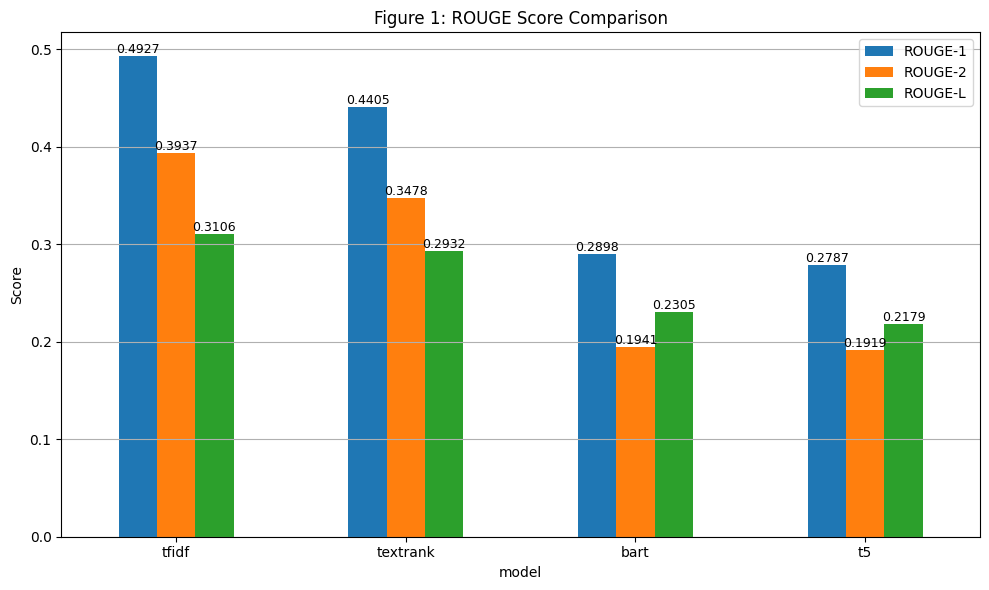

In [90]:
import matplotlib.pyplot as plt

rouge_df_plot = final_df[["model", "ROUGE-1", "ROUGE-2", "ROUGE-L"]].set_index("model")

ax = rouge_df_plot.plot(kind="bar", figsize=(10,6))

plt.title("Figure 1: ROUGE Score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=9)

plt.tight_layout()
plt.show()

### FIGURE 2 — ROUGE-L vs BERTScore divergence

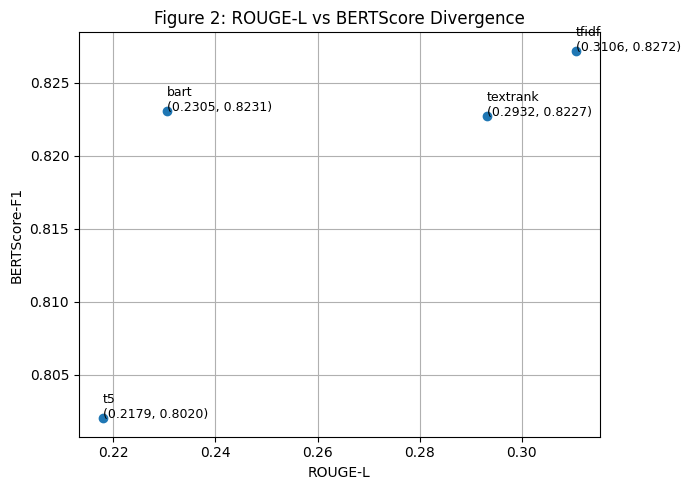

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(final_df["ROUGE-L"], final_df["BERTScore-F1"])

for i, m in enumerate(final_df["model"]):
    x = final_df["ROUGE-L"].iloc[i]
    y = final_df["BERTScore-F1"].iloc[i]

    plt.text(x, y, f"{m}\n({x:.4f}, {y:.4f})", fontsize=9)

plt.xlabel("ROUGE-L")
plt.ylabel("BERTScore-F1")
plt.title("Figure 2: ROUGE-L vs BERTScore Divergence")
plt.grid()
plt.tight_layout()
plt.show()

### FIGURE 3 — Inference Time vs ROUGE-L

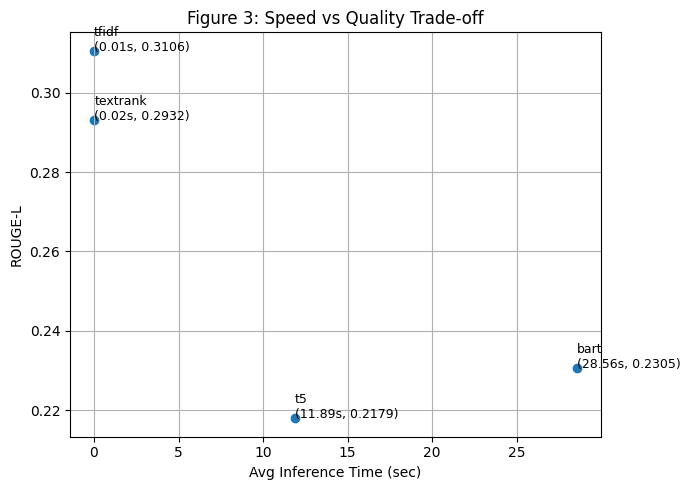

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(final_df["avg_sec"], final_df["ROUGE-L"])

for i in range(len(final_df)):
    x = final_df["avg_sec"].iloc[i]
    y = final_df["ROUGE-L"].iloc[i]
    m = final_df["model"].iloc[i]

    plt.text(
        x, y,
        f"{m}\n({x:.2f}s, {y:.4f})",
        fontsize=9
    )

plt.xlabel("Avg Inference Time (sec)")
plt.ylabel("ROUGE-L")
plt.title("Figure 3: Speed vs Quality Trade-off")
plt.grid()
plt.tight_layout()
plt.show()

### FIGURE 4 — Wilcoxon p-value heatmap

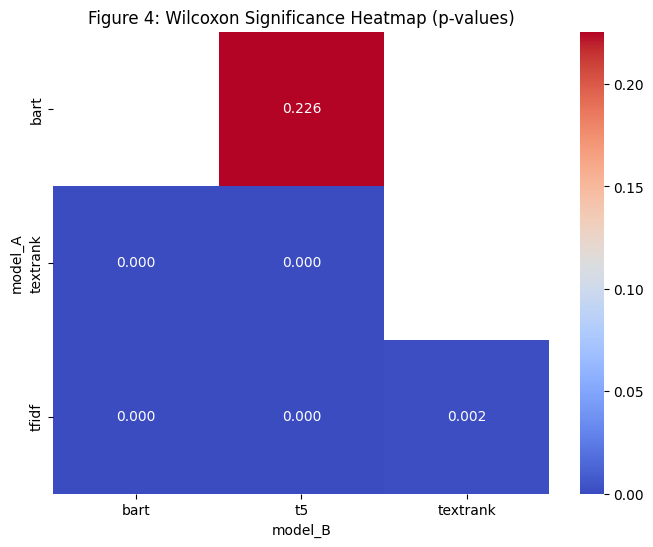

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = wilcoxon_df.pivot_table(
    index="model_A",
    columns="model_B",
    values="p_value",
    aggfunc="mean"   # or "min"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Figure 4: Wilcoxon Significance Heatmap (p-values)")
plt.show()

### FIGURE 5 — Document Length Distribution

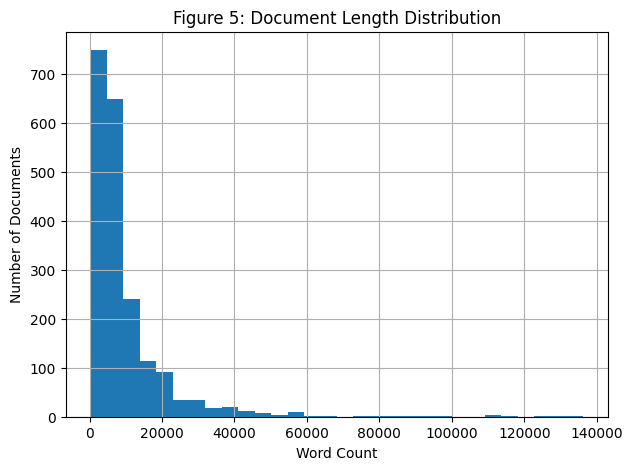

In [80]:
plt.figure(figsize=(7,5))

plt.hist(df["words"], bins=30)
plt.title("Figure 5: Document Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Documents")
plt.grid()
plt.show()

### FIGURE 6 — Year-wise Distribution

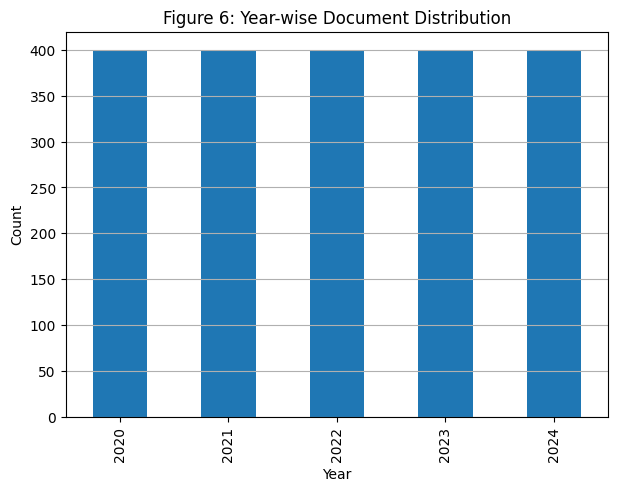

In [83]:
year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(7,5))
year_counts.plot(kind="bar")
plt.title("Figure 6: Year-wise Document Distribution")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(axis="y")
plt.show()

### FIGURE 7 — Radar Chart (Overall Comparison)

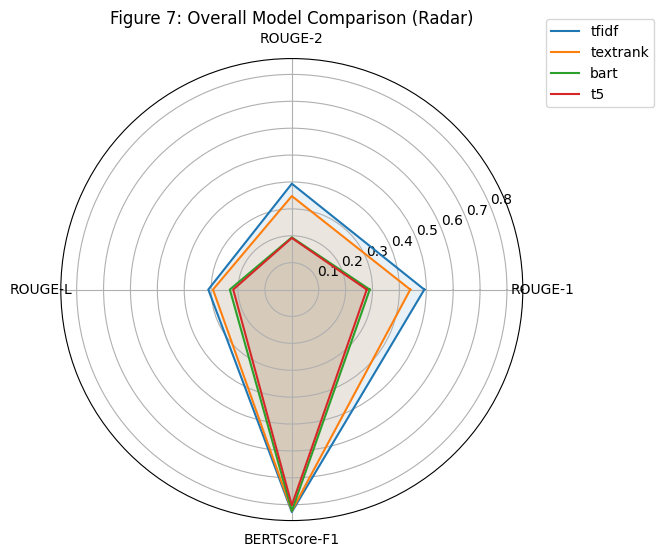

In [86]:
import numpy as np

metrics = ["ROUGE-1","ROUGE-2","ROUGE-L","BERTScore-F1"]
models = final_df["model"].tolist()

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

for i, row in final_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row["model"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
plt.title("Figure 7: Overall Model Comparison (Radar)")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()